This notebook includes runs related to unmixing by using:

1. A very simple CNN, of various different channel sizes. These sizes are:
    - [4, 8]
    - [8, 16]
    - [8, 16, 32]
    - [16, 32, 64]
    - [16, 32, 64, 128]
    - [32, 64, 128, 256]
    - [32, 64, 128, 256, 512]
2. Of varying learning rates fine tuned for the given model.
3. With dropout, optimized using AdamW.
4. A loss of simple MSE, with a small additional terms for sum of residuals.
5. With a training loop that loops over the entire training dataset at each epoch, with a max epochs of 80.
6. Data separated into 1500 training samples, 100 static validation samples, and 123 static test samples.
7. Trained using a GPU.
8. Statistically normalized datasets.
9. Activations of LeakyReLU throughout the model, following BatchNorm, with the final activation layer of ReLU+L1norm.
10. Models initialized using Kaiming (He), tuned for LeakyReLUl leak constant of 0.2.


### Imports, data, model initialization, and various other setups

In [1]:
# Set up autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Sys Imports
import sys
from pathlib import Path

github_root = Path.cwd().resolve().parents[3]
sys.path.append(str(github_root))

In [3]:
# Self-def imports

from src.dl.data import get_data
from src.dl.models.cnn import CNN
from src.dl.train import train_model

In [4]:
# Package imports
import torch
import torch.nn as nn

In [5]:
# Get device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Data hyperparams
save_path = rf"{github_root}\data\simpler_data_rwc.csv"

batch_size = 32
epoch = 100
n_tb_epoch = 47

In [7]:
# Define model configs

models_list = [
    {'hidden_ch': [4, 8]},
    {'hidden_ch': [8, 16]},
    {'hidden_ch': [8, 16, 32]},
    {'hidden_ch': [16, 32, 64]},
    {'hidden_ch': [16, 32, 64, 128]},
    {'hidden_ch': [32, 64, 128, 256]},
    {'hidden_ch': [32, 64, 128, 256, 512]}
]

lr_list = [1e-3, 1.25e-3, 2.5e-3, 5e-3, 7.5e-3, 1e-4, 1e-4]

dir_list = [
    'cnn_8',
    'cnn_16',
    'cnn_32',
    'cnn_64',
    'cnn_128',
    'cnn_256',
    'cnn_512'
]

name_list = [
        'CNN_8',
        'CNN_16',
        'CNN_32',
        'CNN_64',
        'CNN_128',
        'CNN_256',
        'CNN_512'
    ]

# Create dirs

for dir_name in dir_list:
    save_dir = github_root / 'runs' / 'dl' / 'simpler_data' / 'cnn' / dir_name
    save_dir.mkdir(parents=True, exist_ok=True)

### Model train loop

Epoch 1/80, Step 1/47, Train Loss: 0.308575
Epoch 1/80, Step 2/47, Train Loss: 0.257490
Epoch 1/80, Step 3/47, Train Loss: 0.349846
Epoch 1/80, Step 4/47, Train Loss: 0.305369
Epoch 1/80, Step 5/47, Train Loss: 0.317056
Epoch 1/80, Step 6/47, Train Loss: 0.345668
Epoch 1/80, Step 7/47, Train Loss: 0.263955
Epoch 1/80, Step 8/47, Train Loss: 0.219054
Epoch 1/80, Step 9/47, Train Loss: 0.247163
Epoch 1/80, Step 10/47, Train Loss: 0.220201
Epoch 1/80, Step 11/47, Train Loss: 0.276072
Epoch 1/80, Step 12/47, Train Loss: 0.214013
Epoch 1/80, Step 13/47, Train Loss: 0.258695
Epoch 1/80, Step 14/47, Train Loss: 0.251242
Epoch 1/80, Step 15/47, Train Loss: 0.231571
Epoch 1/80, Step 16/47, Train Loss: 0.195499
Epoch 1/80, Step 17/47, Train Loss: 0.187730
Epoch 1/80, Step 18/47, Train Loss: 0.153381
Epoch 1/80, Step 19/47, Train Loss: 0.249511
Epoch 1/80, Step 20/47, Train Loss: 0.157287
Epoch 1/80, Step 21/47, Train Loss: 0.192214
Epoch 1/80, Step 22/47, Train Loss: 0.263623
Epoch 1/80, Step 23

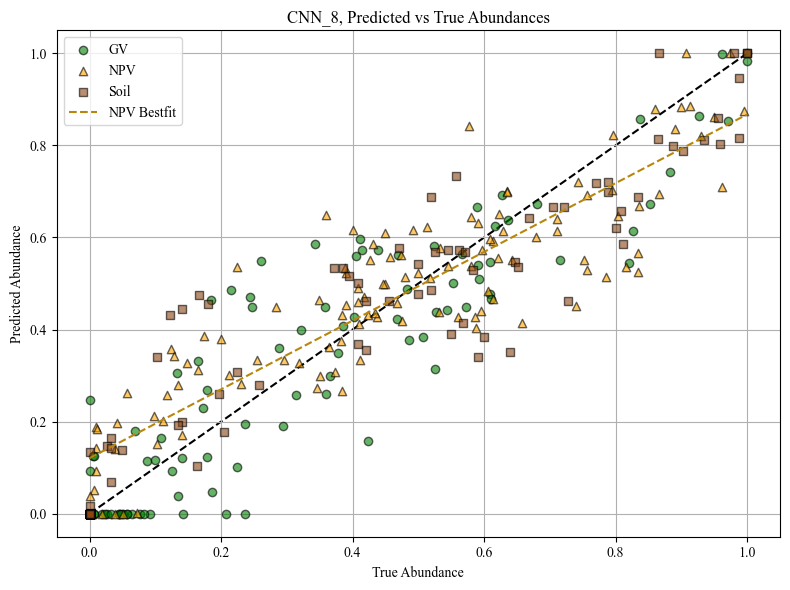

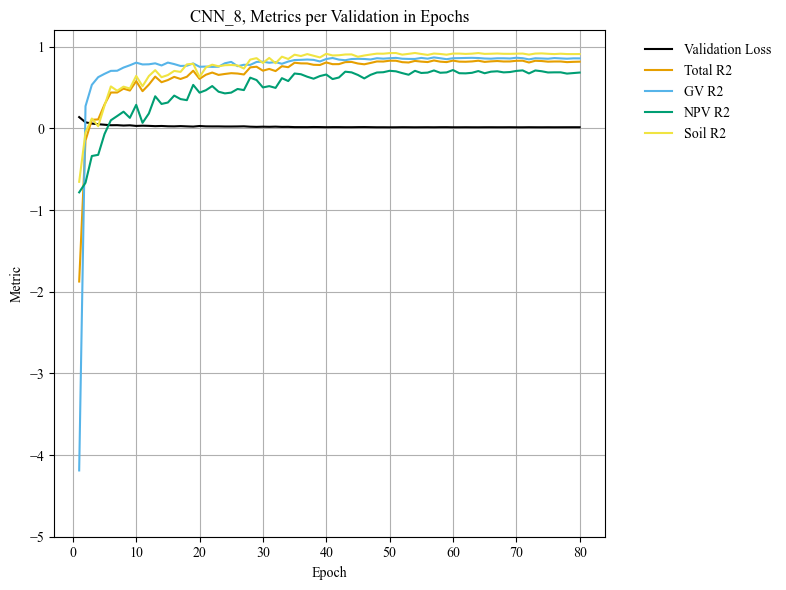

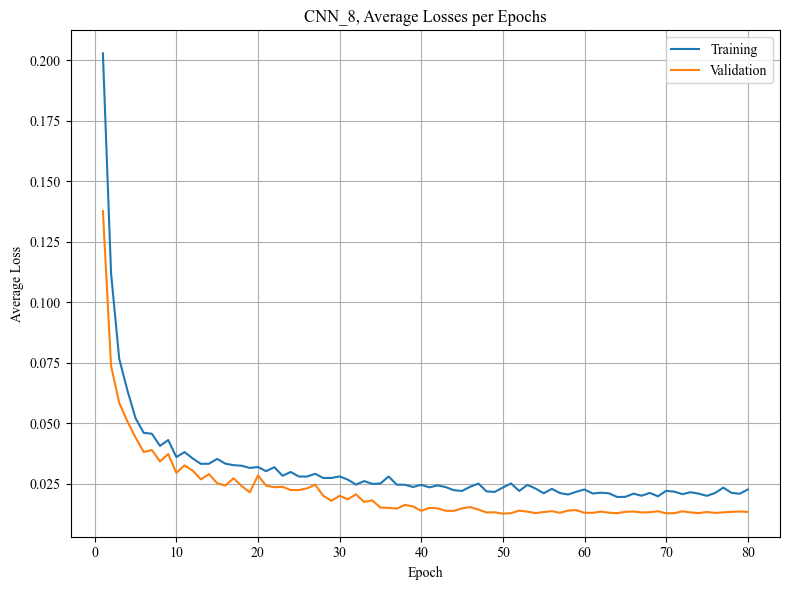

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.278628
Epoch 1/80, Step 2/47, Train Loss: 0.211207
Epoch 1/80, Step 3/47, Train Loss: 0.280231
Epoch 1/80, Step 4/47, Train Loss: 0.229759
Epoch 1/80, Step 5/47, Train Loss: 0.278937
Epoch 1/80, Step 6/47, Train Loss: 0.237894
Epoch 1/80, Step 7/47, Train Loss: 0.218261
Epoch 1/80, Step 8/47, Train Loss: 0.149709
Epoch 1/80, Step 9/47, Train Loss: 0.139308
Epoch 1/80, Step 10/47, Train Loss: 0.218926
Epoch 1/80, Step 11/47, Train Loss: 0.159047
Epoch 1/80, Step 12/47, Train Loss: 0.186195
Epoch 1/80, Step 13/47, Train Loss: 0.220320
Epoch 1/80, Step 14/47, Train Loss: 0.219612
Epoch 1/80, Step 15/47, Train Loss: 0.143385
Epoch 1/80, Step 16/47, Train Loss: 0.181887
Epoch 1/80, Step 17/47, Train Loss: 0.191533
Epoch 1/80, Step 18/47, Train Loss: 0.145479
Epoch 1/80, Step 19/47, Train Loss: 0.136115
Epoch 1/80, Step 20/47, Train Loss: 0.136461
Epoch 1/80, Step 21/47, Train Loss: 0.148909
Epoch 1/80, Step 22/47, Train Loss: 0.241771
Ep

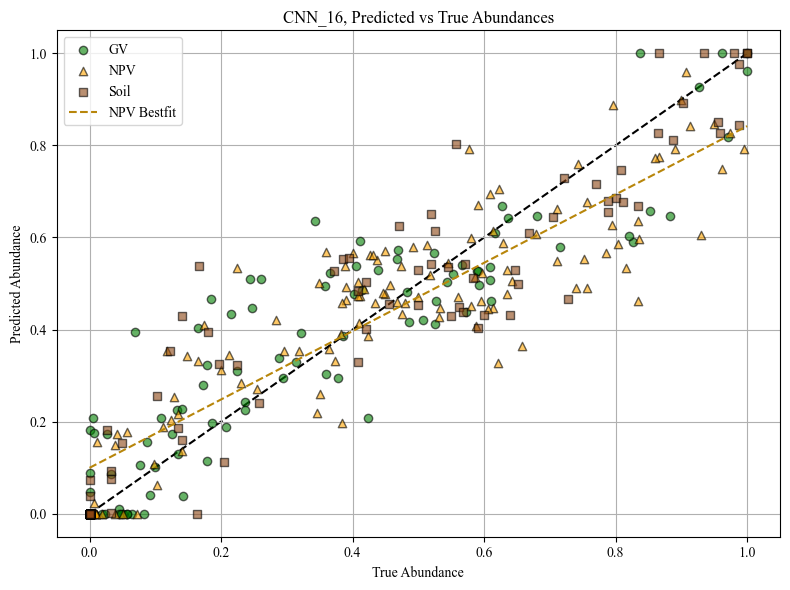

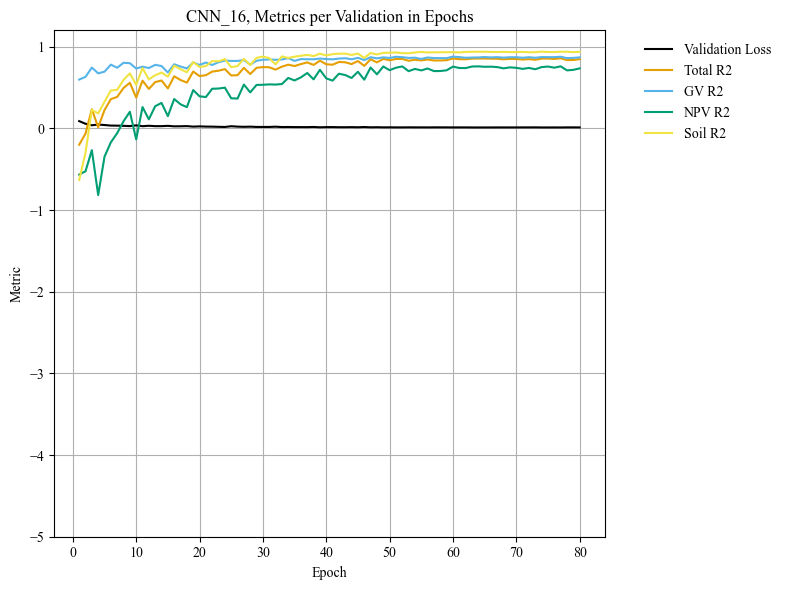

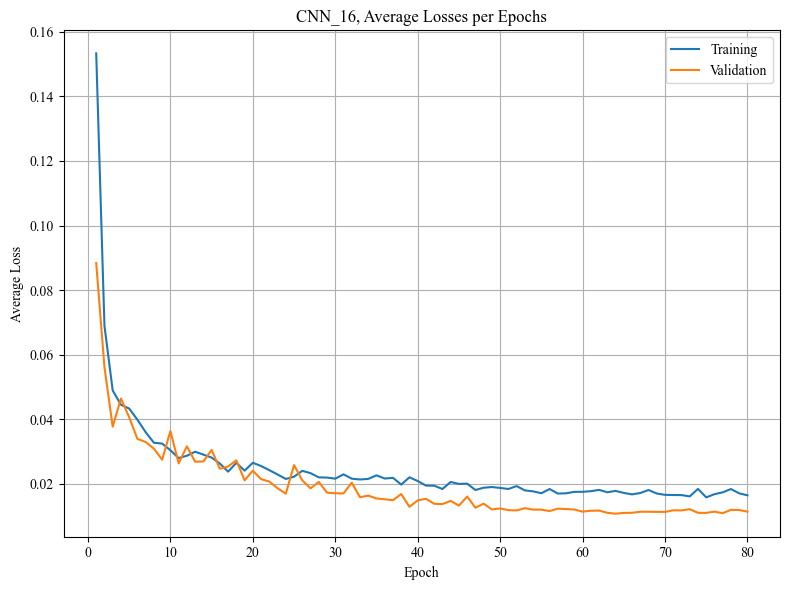

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.229862
Epoch 1/80, Step 2/47, Train Loss: 0.266517
Epoch 1/80, Step 3/47, Train Loss: 0.178794
Epoch 1/80, Step 4/47, Train Loss: 0.186665
Epoch 1/80, Step 5/47, Train Loss: 0.192447
Epoch 1/80, Step 6/47, Train Loss: 0.146694
Epoch 1/80, Step 7/47, Train Loss: 0.153572
Epoch 1/80, Step 8/47, Train Loss: 0.180514
Epoch 1/80, Step 9/47, Train Loss: 0.131476
Epoch 1/80, Step 10/47, Train Loss: 0.140138
Epoch 1/80, Step 11/47, Train Loss: 0.147396
Epoch 1/80, Step 12/47, Train Loss: 0.119600
Epoch 1/80, Step 13/47, Train Loss: 0.121442
Epoch 1/80, Step 14/47, Train Loss: 0.092101
Epoch 1/80, Step 15/47, Train Loss: 0.091364
Epoch 1/80, Step 16/47, Train Loss: 0.087528
Epoch 1/80, Step 17/47, Train Loss: 0.084578
Epoch 1/80, Step 18/47, Train Loss: 0.082895
Epoch 1/80, Step 19/47, Train Loss: 0.110749
Epoch 1/80, Step 20/47, Train Loss: 0.097256
Epoch 1/80, Step 21/47, Train Loss: 0.084845
Epoch 1/80, Step 22/47, Train Loss: 0.057758
Ep

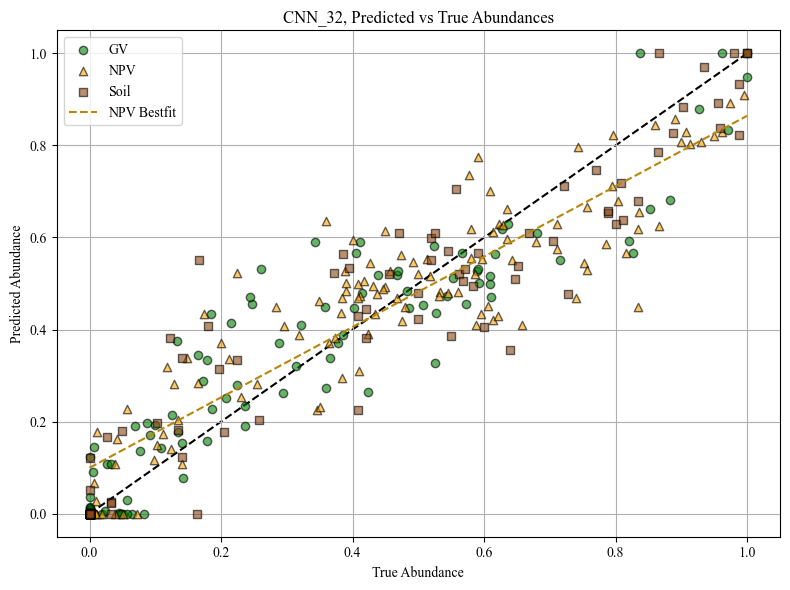

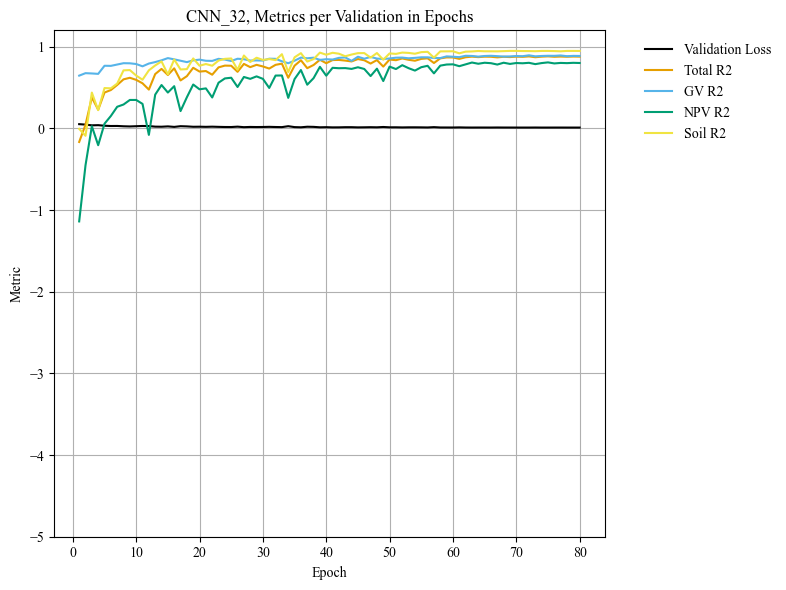

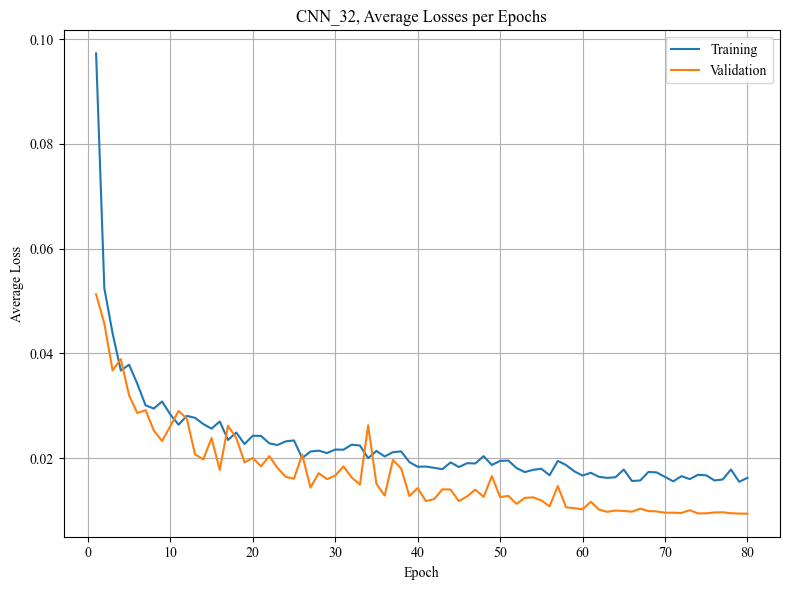

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.246769
Epoch 1/80, Step 2/47, Train Loss: 0.259966
Epoch 1/80, Step 3/47, Train Loss: 0.267477
Epoch 1/80, Step 4/47, Train Loss: 0.201344
Epoch 1/80, Step 5/47, Train Loss: 0.160224
Epoch 1/80, Step 6/47, Train Loss: 0.154748
Epoch 1/80, Step 7/47, Train Loss: 0.118262
Epoch 1/80, Step 8/47, Train Loss: 0.129727
Epoch 1/80, Step 9/47, Train Loss: 0.096433
Epoch 1/80, Step 10/47, Train Loss: 0.093104
Epoch 1/80, Step 11/47, Train Loss: 0.086799
Epoch 1/80, Step 12/47, Train Loss: 0.079455
Epoch 1/80, Step 13/47, Train Loss: 0.081594
Epoch 1/80, Step 14/47, Train Loss: 0.093119
Epoch 1/80, Step 15/47, Train Loss: 0.075658
Epoch 1/80, Step 16/47, Train Loss: 0.070505
Epoch 1/80, Step 17/47, Train Loss: 0.071999
Epoch 1/80, Step 18/47, Train Loss: 0.079405
Epoch 1/80, Step 19/47, Train Loss: 0.058495
Epoch 1/80, Step 20/47, Train Loss: 0.059680
Epoch 1/80, Step 21/47, Train Loss: 0.071729
Epoch 1/80, Step 22/47, Train Loss: 0.055619
Ep

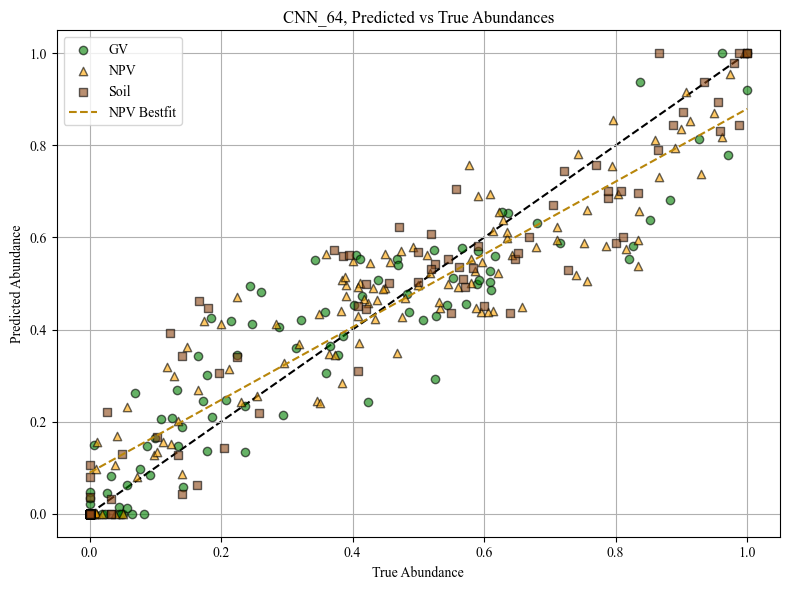

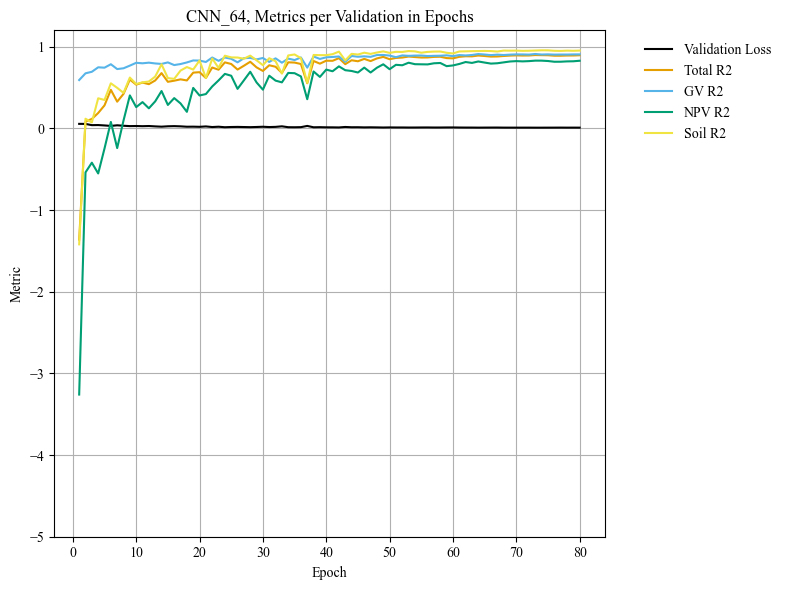

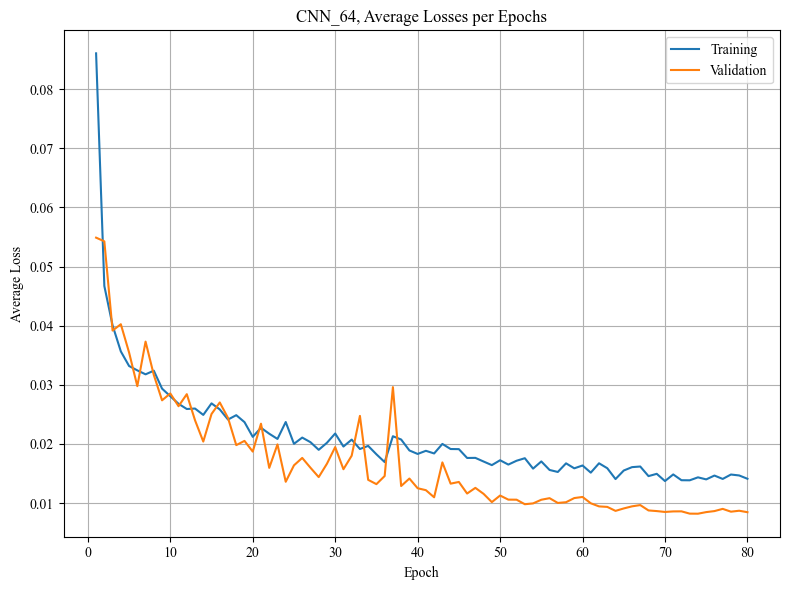

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.184320
Epoch 1/80, Step 2/47, Train Loss: 0.118823
Epoch 1/80, Step 3/47, Train Loss: 0.062869
Epoch 1/80, Step 4/47, Train Loss: 0.102137
Epoch 1/80, Step 5/47, Train Loss: 0.062138
Epoch 1/80, Step 6/47, Train Loss: 0.074539
Epoch 1/80, Step 7/47, Train Loss: 0.073056
Epoch 1/80, Step 8/47, Train Loss: 0.094287
Epoch 1/80, Step 9/47, Train Loss: 0.065531
Epoch 1/80, Step 10/47, Train Loss: 0.057007
Epoch 1/80, Step 11/47, Train Loss: 0.075315
Epoch 1/80, Step 12/47, Train Loss: 0.055167
Epoch 1/80, Step 13/47, Train Loss: 0.068096
Epoch 1/80, Step 14/47, Train Loss: 0.071994
Epoch 1/80, Step 15/47, Train Loss: 0.066414
Epoch 1/80, Step 16/47, Train Loss: 0.066983
Epoch 1/80, Step 17/47, Train Loss: 0.048820
Epoch 1/80, Step 18/47, Train Loss: 0.047582
Epoch 1/80, Step 19/47, Train Loss: 0.057446
Epoch 1/80, Step 20/47, Train Loss: 0.046019
Epoch 1/80, Step 21/47, Train Loss: 0.064375
Epoch 1/80, Step 22/47, Train Loss: 0.045871
Ep

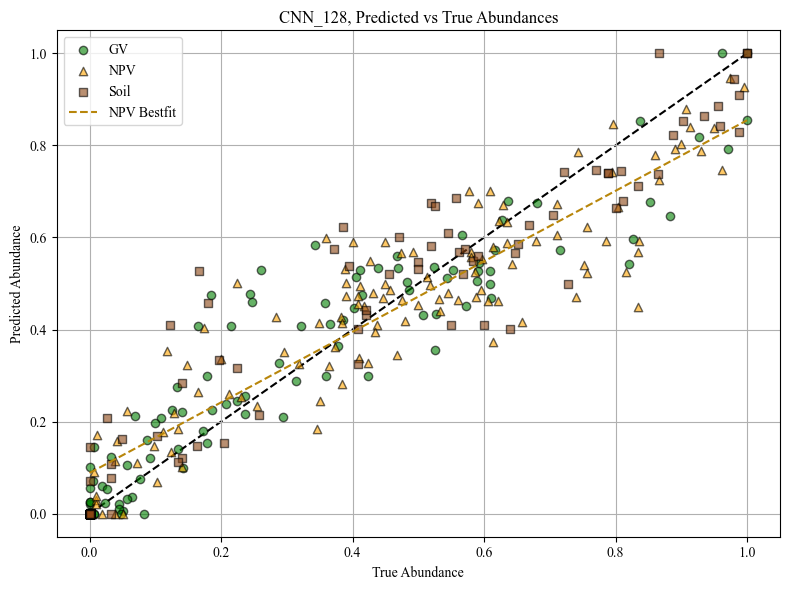

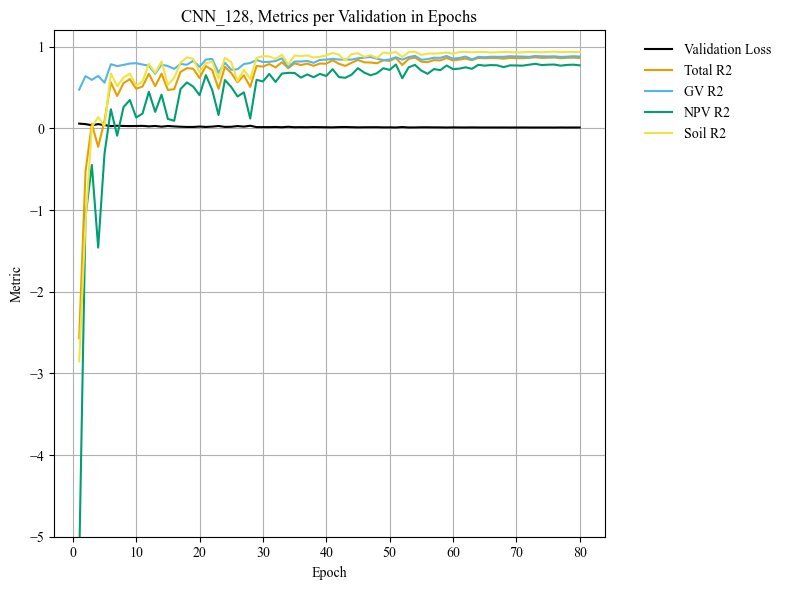

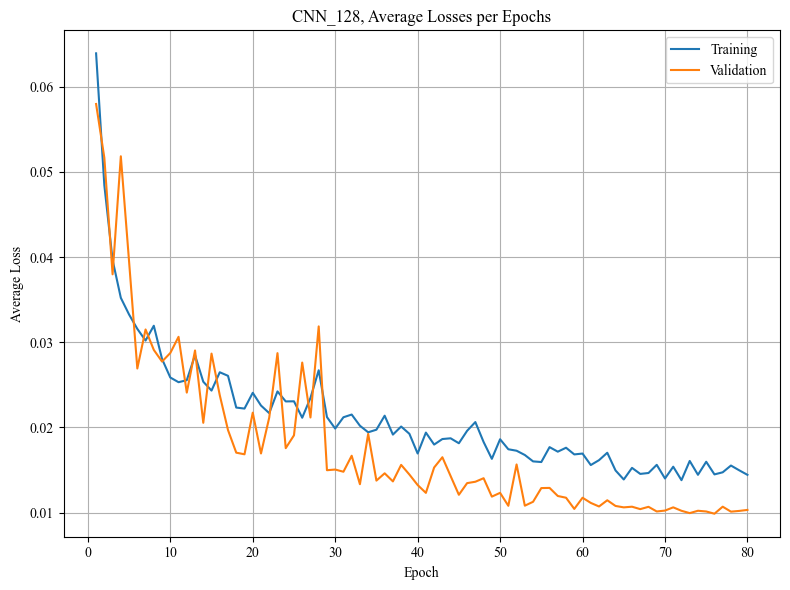

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.232181
Epoch 1/80, Step 2/47, Train Loss: 0.194890
Epoch 1/80, Step 3/47, Train Loss: 0.178341
Epoch 1/80, Step 4/47, Train Loss: 0.144578
Epoch 1/80, Step 5/47, Train Loss: 0.226956
Epoch 1/80, Step 6/47, Train Loss: 0.209348
Epoch 1/80, Step 7/47, Train Loss: 0.149933
Epoch 1/80, Step 8/47, Train Loss: 0.151461
Epoch 1/80, Step 9/47, Train Loss: 0.161615
Epoch 1/80, Step 10/47, Train Loss: 0.116398
Epoch 1/80, Step 11/47, Train Loss: 0.142042
Epoch 1/80, Step 12/47, Train Loss: 0.116798
Epoch 1/80, Step 13/47, Train Loss: 0.123841
Epoch 1/80, Step 14/47, Train Loss: 0.141616
Epoch 1/80, Step 15/47, Train Loss: 0.122723
Epoch 1/80, Step 16/47, Train Loss: 0.095561
Epoch 1/80, Step 17/47, Train Loss: 0.092724
Epoch 1/80, Step 18/47, Train Loss: 0.082957
Epoch 1/80, Step 19/47, Train Loss: 0.093103
Epoch 1/80, Step 20/47, Train Loss: 0.079229
Epoch 1/80, Step 21/47, Train Loss: 0.086789
Epoch 1/80, Step 22/47, Train Loss: 0.057079
Ep

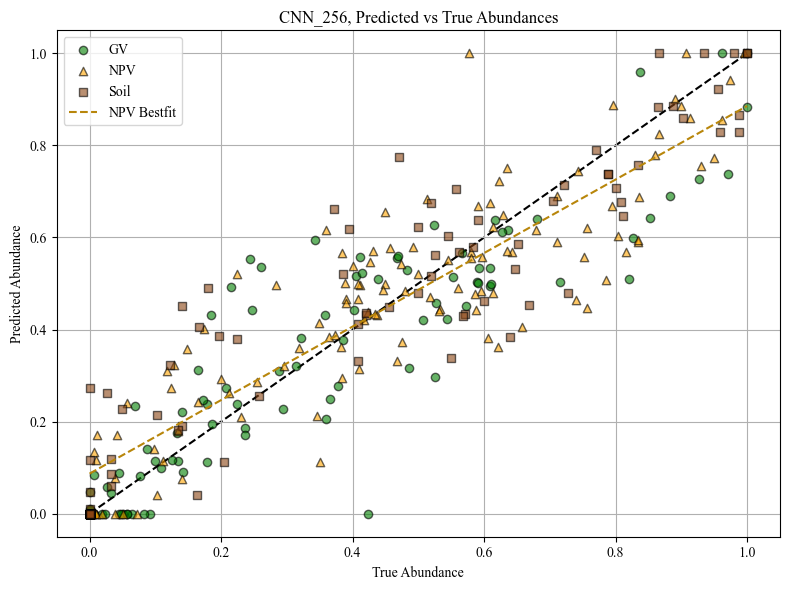

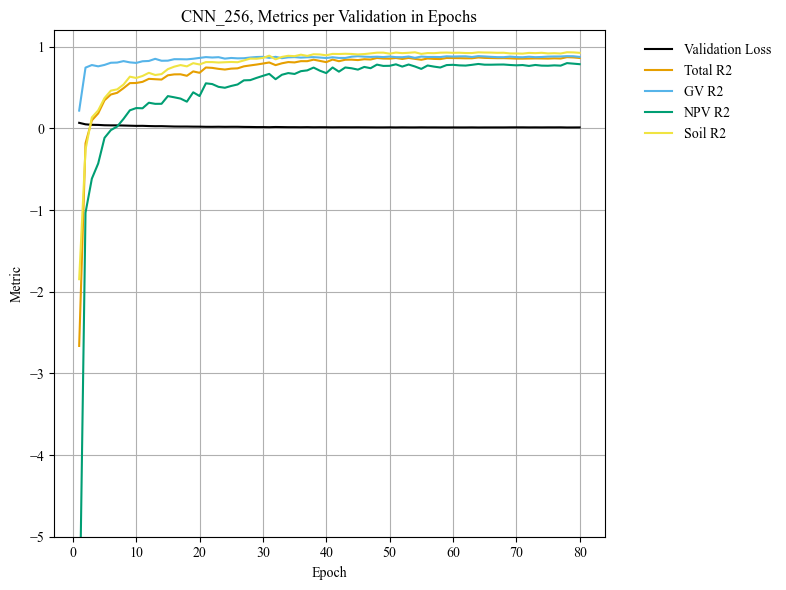

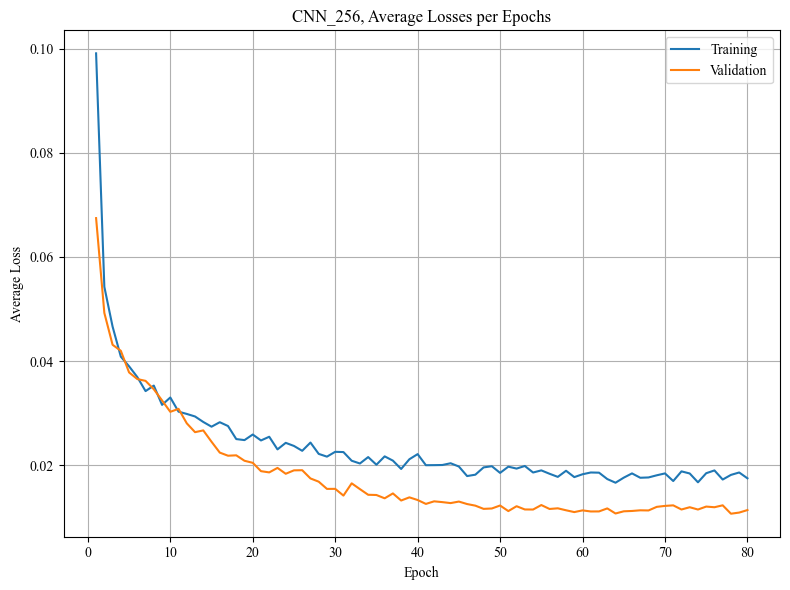

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.224878
Epoch 1/80, Step 2/47, Train Loss: 0.230982
Epoch 1/80, Step 3/47, Train Loss: 0.211011
Epoch 1/80, Step 4/47, Train Loss: 0.231294
Epoch 1/80, Step 5/47, Train Loss: 0.134313
Epoch 1/80, Step 6/47, Train Loss: 0.145931
Epoch 1/80, Step 7/47, Train Loss: 0.147908
Epoch 1/80, Step 8/47, Train Loss: 0.135231
Epoch 1/80, Step 9/47, Train Loss: 0.121493
Epoch 1/80, Step 10/47, Train Loss: 0.095487
Epoch 1/80, Step 11/47, Train Loss: 0.129781
Epoch 1/80, Step 12/47, Train Loss: 0.086058
Epoch 1/80, Step 13/47, Train Loss: 0.059714
Epoch 1/80, Step 14/47, Train Loss: 0.100576
Epoch 1/80, Step 15/47, Train Loss: 0.080165
Epoch 1/80, Step 16/47, Train Loss: 0.088784
Epoch 1/80, Step 17/47, Train Loss: 0.076706
Epoch 1/80, Step 18/47, Train Loss: 0.061119
Epoch 1/80, Step 19/47, Train Loss: 0.068451
Epoch 1/80, Step 20/47, Train Loss: 0.067754
Epoch 1/80, Step 21/47, Train Loss: 0.058504
Epoch 1/80, Step 22/47, Train Loss: 0.092317
Ep

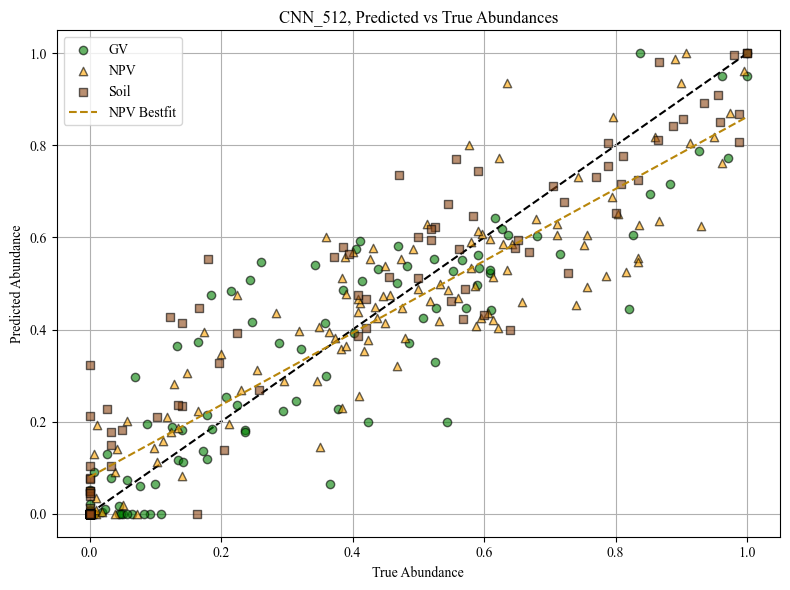

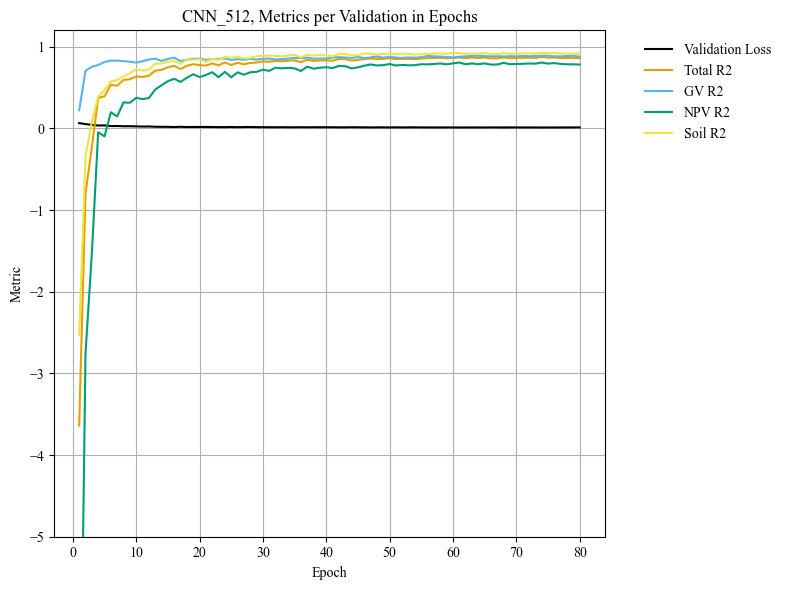

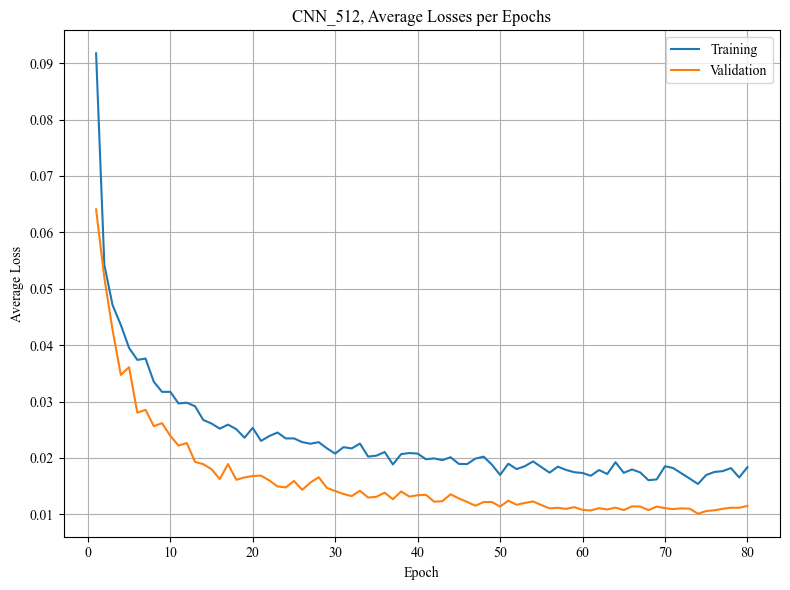

Testing complete


In [ ]:
cnn_dict = {}

for i in range(len(models_list)):
    
    cfg_dict = models_list[i]
    lr = lr_list[i]
    save_dir = github_root / 'runs' / 'dl' / 'simpler_data' / 'cnn' / dir_list[i]
    model_name = name_list[i]

    dataloaders = get_data(save_path=save_path, spec_range=[900, 1690], batch_size=32, SNV=True)
    model = CNN(**cfg_dict).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epoch*n_tb_epoch, eta_min=1e-6)
    loss = nn.MSELoss()

    model_dict = train_model(
        model=model,
        loss_fn=loss,
        optimizer=optimizer,
        lr_scheduler=lr_scheduler,
        configured_data=dataloaders,
        n_epoch=epoch,
        n_tb_epoch=n_tb_epoch,
        device=device,
        dtype=torch.float32,
        save_dir=save_dir,
        model_name=model_name,
        fine_tuning=False
    )

    cnn_dict[model_name] = model_dict

In [9]:
import pickle
with open('cnn_dict.pkl', 'wb') as fp:
    pickle.dump(cnn_dict, fp)

In [10]:
# Best model
print(cnn_dict['CNN_64']['metrics_total'])

[[3.33210000e+04 1.31930200e+06 9.55175888e-03 8.64921033e-01
  8.74257803e-01 7.91044831e-01 9.29460406e-01 6.67294785e-02
  6.41604066e-02 8.55138302e-02 5.05141951e-02]]


In [11]:
for i in cnn_dict.keys():
    print(f"For {i}, NPV R2: {cnn_dict[i]['metrics_total'][0][5]}, param#: {cnn_dict[i]['metrics_total'][0][0]}")

For CNN_8, NPV R2: 0.7065660953521729, param#: 11185.0
For CNN_16, NPV R2: 0.6898836493492126, param#: 12089.0
For CNN_32, NPV R2: 0.7399064302444458, param#: 16633.0
For CNN_64, NPV R2: 0.7910448312759399, param#: 33321.0
For CNN_128, NPV R2: 0.7517417073249817, param#: 103721.0
For CNN_256, NPV R2: 0.7382253408432007, param#: 379401.0
For CNN_512, NPV R2: 0.7327121496200562, param#: 1496585.0
